# Tutorial: Mock Interferometer Imaging

This tutorial uses `fast_interferometer` to simulate dirty maps from a mock antenna array.

The sky map must have shape `(y_npix, x_npix)` — the same dimensions passed to the instrument constructor. UV coverage is gridded from the field of view (`theta_x`, `theta_y`) and baseline geometry at the observing frequency.


## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units

from limstat.fast_interferometer import fast_interferometer

np.random.seed(42)

%load_ext autoreload
%autoreload 2


## Observation setup

We use 150 MHz and a square field of view. Set `npix` for both the instrument grid and the sky map (they must match).


In [3]:
freq = 150 * units.MHz
wavelength = (3e8 * units.m / units.s / freq.to(units.Hz)).to(units.m)

fov = 10 * units.deg
theta = fov
npix = 96

T_sys = 200 * units.K
t_obs = 1000 * units.hr
bandwidth = 8 * units.MHz

print(f'Frequency: {freq}')
print(f'Wavelength: {wavelength:.3f}')
print(f'Field of view: {fov}')
print(f'Image / UV grid: {npix} x {npix} pixels')


Frequency: 150.0 MHz
Wavelength: 2.000 m
Field of view: 10.0 deg
Image / UV grid: 96 x 96 pixels


## Mock true sky

Shape must be `(y_npix, x_npix)`.


In [4]:
yy, xx = np.mgrid[0:npix, 0:npix]
cy, cx = npix // 2, npix // 2

sigma = npix / 8
smooth = 5.0 * np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))

point = np.zeros_like(smooth)
point[cy + 12, cx - 15] = 80.0

true_sky_mK = point
true_sky = (true_sky_mK * units.mK).to(units.K).value

assert true_sky.shape == (npix, npix)
print(f'True sky shape: {true_sky.shape}')


True sky shape: (96, 96)


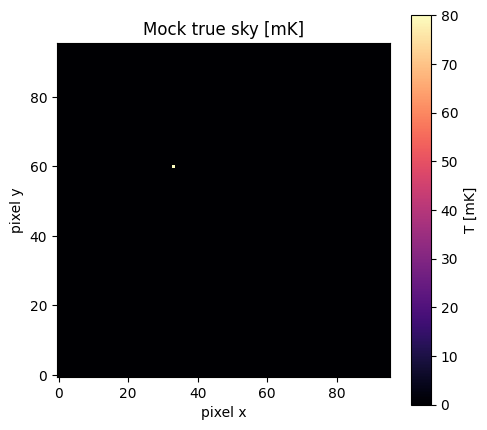

In [5]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(true_sky_mK, origin='lower', cmap='magma')
ax.set_title('Mock true sky [mK]')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.colorbar(im, ax=ax, label='T [mK]')
plt.tight_layout()


## Mock antenna array

Two helper functions build antenna coordinates (astropy `units.m`):

- **`mock_grid`** — perturbed regular grid inside the aperture
- **`mock_random`** — uniform random positions inside the aperture

Set `ARRAY_LAYOUT` to `'grid'` or `'random'` to choose which layout to use.


In [6]:
def mock_grid(n_ants=12, aperture_m=30.0, seed=42, perturbation = 0):
    """Antennas on a perturbed regular grid inside a square aperture."""
    rng = np.random.default_rng(seed)
    grid_side = int(np.ceil(np.sqrt(n_ants)))
    xs = np.linspace(-aperture_m / 2, aperture_m / 2, grid_side)
    ys = np.linspace(-aperture_m / 2, aperture_m / 2, grid_side)
    xx, yy = np.meshgrid(xs, ys)
    coords = np.column_stack([xx.ravel(), yy.ravel()])[:n_ants]
    coords += rng.normal(0, perturbation, coords.shape)
    return coords * units.m


def mock_random(n_ants=12, aperture_m=30.0, seed=42):
    """Antennas placed at random positions inside a square aperture."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(-aperture_m / 2, aperture_m / 2, size=(n_ants, 2))
    return coords * units.m

ARRAY_LAYOUT = 'random'  # 'grid' or 'random'

n_ants = 40
aperture_m = 300.0
seed = 0

if ARRAY_LAYOUT == 'grid':
    ant_locs = mock_grid(n_ants=n_ants, aperture_m=aperture_m, seed=seed)
elif ARRAY_LAYOUT == 'random':
    ant_locs = mock_random(n_ants=n_ants, aperture_m=aperture_m, seed=seed)
else:
    raise ValueError("ARRAY_LAYOUT must be 'grid' or 'random'")

print(f'Layout: {ARRAY_LAYOUT}')
print(f'{ant_locs.shape[0]} antennas, aperture = {aperture_m} m')


Layout: random
40 antennas, aperture = 300.0 m


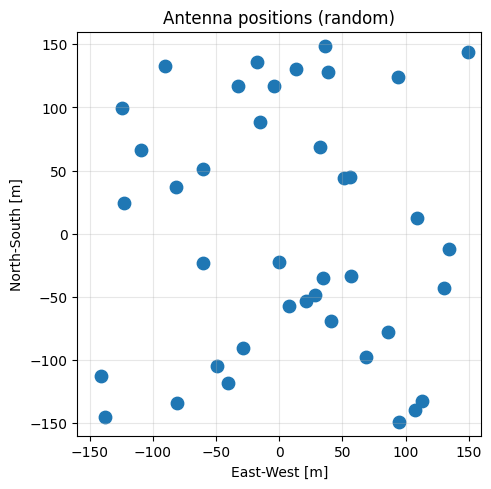

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    ant_locs[:, 0].to(units.m).value,
    ant_locs[:, 1].to(units.m).value,
    s=80,
    c='C0',
)

ax.set_xlim(-aperture_m / 2-10, aperture_m / 2+10)
ax.set_ylim(-aperture_m / 2-10, aperture_m / 2+10)
ax.set_xlabel('East-West [m]')
ax.set_ylabel('North-South [m]')
ax.set_title(f'Antenna positions ({ARRAY_LAYOUT})')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()


## Build the instrument and baselines


In [8]:
instrument = fast_interferometer(
    ant_locs=ant_locs,
    theta_x=theta,
    theta_y=theta,
    x_npix=npix,
    y_npix=npix,
    T_sys=T_sys,
    t_obs=t_obs,
    bandwidth=bandwidth,
)

bls = instrument.get_bls(freq)
print(f'{bls.shape[0]} unique baseline vectors (including -u,-v pairs)')


1560 total baseline vectors, 1560 unique baseline vectors
1560 unique baseline vectors (including -u,-v pairs)


## UV coverage

`get_uvmap_halfwave(freq)` grids baselines onto a half-wave UV lattice (``du = dv = 0.5`` wavelengths). Redundant baselines increment ``count_map``.


In [9]:
uv_map_halfwave = instrument.get_uvmap_halfwave(freq)

1560 total baseline vectors, 1560 unique baseline vectors


In [10]:
u,v,l,m,dl,dm = instrument.sky_uv_coords()

In [11]:
sky_fft = instrument.sky_fft_to_uv(true_sky)
V_hw, uv_map = instrument.interp_sky_fft_to_halfwave(true_sky, freq)


1560 total baseline vectors, 1560 unique baseline vectors


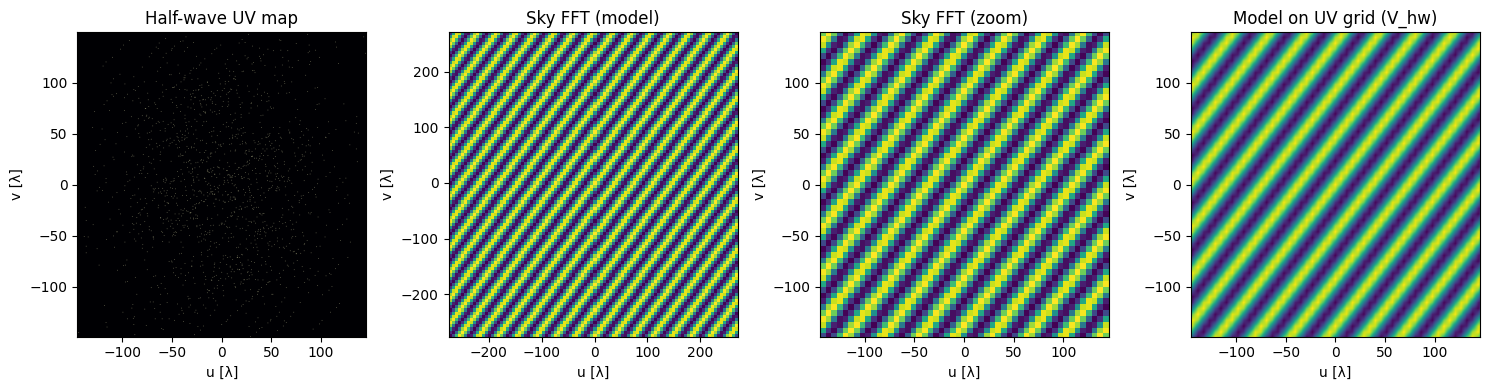

In [12]:
u_extent = [instrument.u_grid[0], instrument.u_grid[-1]]
v_extent = [instrument.v_grid[0], instrument.v_grid[-1]]
sky_u_extent = [u[0], u[-1]]
sky_v_extent = [v[0], v[-1]]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(
    uv_map_halfwave,
    origin='lower',
    extent=[*u_extent, *v_extent],
    aspect='auto',
    cmap='magma'
)
axes[0].set_xlabel('u [λ]')
axes[0].set_ylabel('v [λ]')
axes[0].set_title('Half-wave UV map')

axes[1].imshow(
    sky_fft.real,
    origin='lower',
    extent=[*sky_u_extent, *sky_v_extent],
    aspect='auto',
)
axes[1].set_xlabel('u [λ]')
axes[1].set_ylabel('v [λ]')
axes[1].set_title('Sky FFT (model)')

axes[2].imshow(
    sky_fft.real,
    origin='lower',
    extent=[*sky_u_extent, *sky_v_extent],
    aspect='auto',
)
axes[2].set_xlim(u_extent)
axes[2].set_ylim(v_extent)
axes[2].set_xlabel('u [λ]')
axes[2].set_ylabel('v [λ]')
axes[2].set_title('Sky FFT (zoom)')

axes[3].imshow(
    V_hw.real,
    origin='lower',
    extent=[*u_extent, *v_extent],
    aspect='auto',
)
axes[3].set_xlabel('u [λ]')
axes[3].set_ylabel('v [λ]')
axes[3].set_title('Model on UV grid (V_hw)')

plt.tight_layout()


In [13]:
obs_map = instrument.get_dirty_map(true_sky, freq, noise=False)
print(f'Noiseless dirty map shape: {obs_map.shape}')


1560 total baseline vectors, 1560 unique baseline vectors
Noiseless dirty map shape: (96, 96)


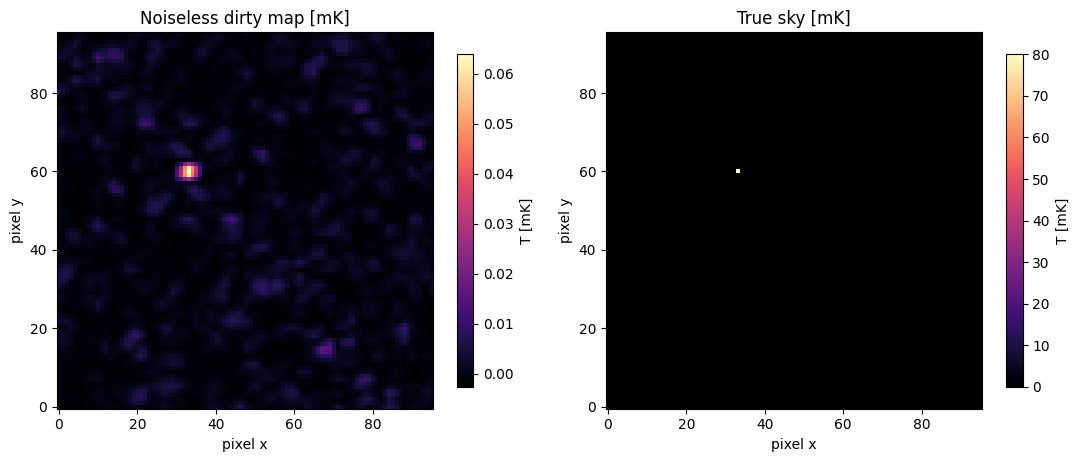

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im1 = axes[0].imshow(obs_map * 1e3, origin='lower', cmap='magma')
#colorbar for map 
plt.colorbar(im1, ax=axes[0], label='T [mK]', shrink=0.85)
axes[0].set_title('Noiseless dirty map [mK]')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')


im2 = axes[1].imshow(true_sky_mK, origin='lower', cmap='magma')
plt.colorbar(im2, ax=axes[1], label='T [mK]', shrink=0.85)
axes[1].set_title('True sky [mK]')
axes[1].set_xlabel('pixel x')
axes[1].set_ylabel('pixel y')

plt.tight_layout()


## Point spread function

`get_psf` Fourier-transforms the UV coverage mask.


In [15]:
psf = instrument.get_psf(freq)
print(f'PSF shape: {psf.shape}')


1560 total baseline vectors, 1560 unique baseline vectors
PSF shape: (96, 96)


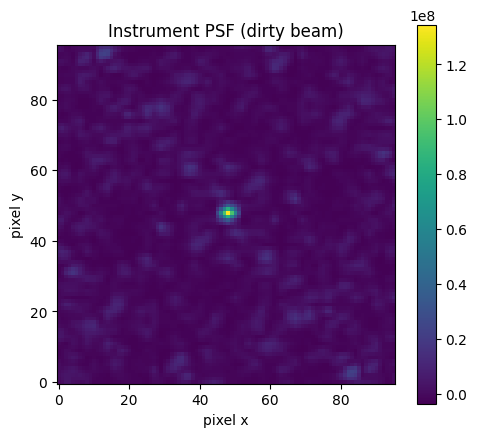

In [16]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(psf, origin='lower', cmap='viridis')
ax.set_title('Instrument PSF (dirty beam)')
ax.set_xlabel('pixel x')
ax.set_ylabel('pixel y')
plt.colorbar(im, ax=ax)
plt.tight_layout()


## Dirty map with noise

Pass ``noise=True`` for thermal noise in the UV plane. With ``redundancy=True``, the noise scale is divided by ``sqrt(count_map)`` in each UV bin. `get_noise_map` returns a noise-only image (complex noise is divided by ``sqrt(2)`` before imaging).


In [36]:
dirty_noisy = instrument.get_dirty_map(
    true_sky, freq, noise=True, redundancy=True,
)
noise_map = instrument.get_noise_map(freq, redundancy=True)

print(f'Per-visibility noise scale (approx): {instrument.compute_noise():.3e} K')


1560 total baseline vectors, 1560 unique baseline vectors
1560 total baseline vectors, 1560 unique baseline vectors
Per-visibility noise scale (approx): 1.135e-06 K


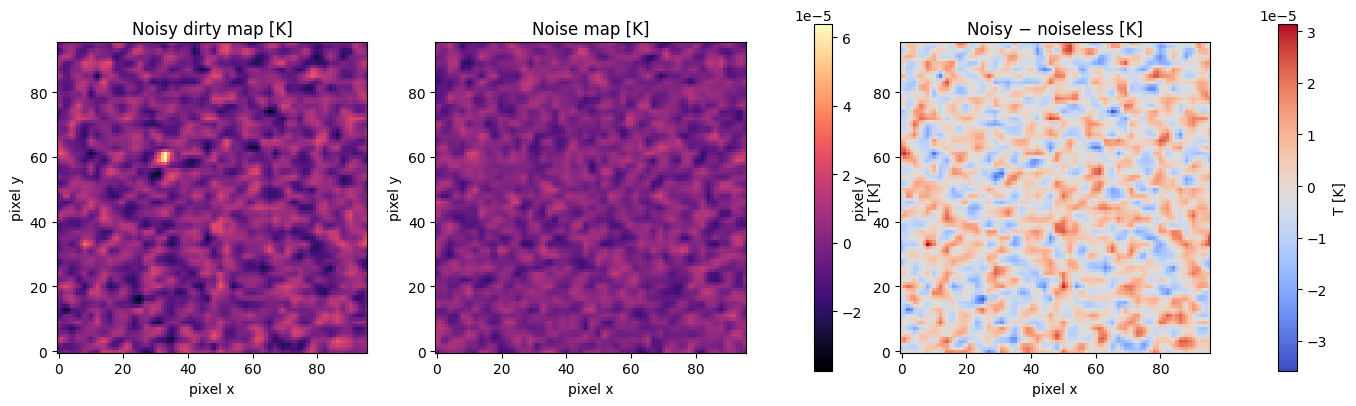

In [37]:
from matplotlib.gridspec import GridSpec

residual = dirty_noisy - obs_map
extent = [-0.5, npix - 0.5, -0.5, npix - 0.5]
vmin = dirty_noisy.min()
vmax = dirty_noisy.max()

fig = plt.figure(figsize=(16, 4.5))
gs = GridSpec(
    1, 5, figure=fig,
    width_ratios=[1, 1, 0.06, 1, 0.06],
    wspace=0.35,
)

ax0 = fig.add_subplot(gs[0, 0], aspect='equal')
ax1 = fig.add_subplot(gs[0, 1], aspect='equal')
cax_shared = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3], aspect='equal')
cax_resid = fig.add_subplot(gs[0, 4])

im0 = ax0.imshow(
    dirty_noisy, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, extent=extent,
)
ax0.set_title('Noisy dirty map [K]')

im1 = ax1.imshow(
    noise_map, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, extent=extent,
)
ax1.set_title('Noise map [K]')

im2 = ax2.imshow(
    residual, origin='lower', cmap='coolwarm', extent=extent,
)
ax2.set_title('Noisy − noiseless [K]')

for ax in (ax0, ax1, ax2):
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel('pixel x')
    ax.set_ylabel('pixel y')

fig.colorbar(im1, cax=cax_shared, label='T [K]')
fig.colorbar(im2, cax=cax_resid, label='T [K]')


## Dirty cube (multi-frequency)

For a simulation cube ``(y_npix, x_npix, n_freq)`` with frequency on the last axis, ``get_dirty_cube`` images each channel with the correct UV coverage at that frequency (and independent noise if enabled).

The **u mode** probed by a physical baseline ``b`` (meters) is ``u = b / λ = b ν / c``. At fixed ``b``, a higher observing frequency maps the same baseline to a larger ``u`` — so each channel in the cube must be imaged with its own UV grid.

In the plot below, you can see that the UV coverage (and therefore PSF) is slightly different for each channel and that the noise realization is independent for each channel. 


In [41]:
n_freq_cube = 3
freqs_cube = np.linspace(140, 160, n_freq_cube) * units.MHz

sky_cube = np.stack(
    [true_sky * (1.0 + 0.05 * i) for i in range(n_freq_cube)],
    axis=2,
)
assert sky_cube.shape == (npix, npix, n_freq_cube)

dirty_cube = instrument.get_dirty_cube(sky_cube, freqs_cube, noise=True)
print(f'Dirty cube shape: {dirty_cube.shape}')


1560 total baseline vectors, 1560 unique baseline vectors
1560 total baseline vectors, 1560 unique baseline vectors
1560 total baseline vectors, 1560 unique baseline vectors
Dirty cube shape: (96, 96, 3)


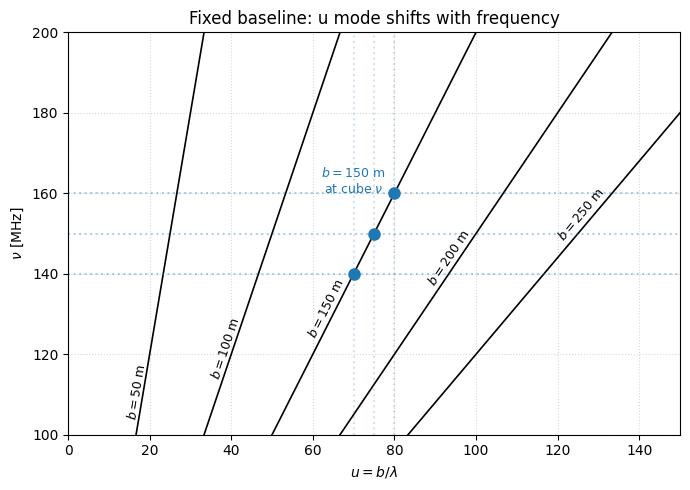

In [58]:
c_light = 3e8  # m/s
baselines_m = [50, 100, 150, 200, 250]
nu_mhz = np.linspace(100, 200, 200)

fig, ax = plt.subplots(figsize=(7, 5))

# Anchor ν (MHz) on each line for labels — inside axes, staggered to avoid overlap
label_nu_mhz = {50: 112, 100: 122, 150: 132, 200: 145, 250: 156}

for b in baselines_m:
    u = b * nu_mhz * 1e6 / c_light
    ax.plot(u, nu_mhz, 'k-', lw=1.2)

    nu_lbl = label_nu_mhz[b] - 10
    u_lbl = (b * nu_lbl * 1e6 / c_light)-1
    u0 = b * 100e6 / c_light
    u1 = b * 200e6 / c_light
    angle = np.degrees(np.arctan2(100, u1 - u0))

    ax.annotate(
        f'$b = {b}$ m',
        xy=(u_lbl, nu_lbl),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=9,
        rotation=angle,
        rotation_mode='anchor',
        va='bottom',
        ha='left',
    )

# Example: one baseline at the three cube frequencies
b_example = 150.0
nu_chan_mhz = freqs_cube.to(units.MHz).value
u_chan = b_example * nu_chan_mhz * 1e6 / c_light
ax.plot(u_chan, nu_chan_mhz, 'o', color='C0', ms=8, zorder=5)
for nu_i, u_i in zip(nu_chan_mhz, u_chan):
    ax.axhline(nu_i, color='C0', ls=':', alpha=0.35)
    ax.axvline(u_i, color='C0', ls=':', alpha=0.2)
ax.text(
    u_chan[-1]-10, nu_chan_mhz[-1],
    f'$b = {b_example:.0f}$ m \nat cube $\\nu$',
    color='C0', fontsize=9, ha='center',
)

ax.set_xlabel(r'$u = b / \lambda$')
ax.set_ylabel(r'$\nu$ [MHz]')
ax.set_xlim(0, 150)
ax.set_ylim(100, 200)
ax.grid(True, ls=':', alpha=0.5)
ax.set_title('Fixed baseline: u mode shifts with frequency')
plt.tight_layout()

/var/folders/4v/cpjslnh12z99vhr9_z5vv0640000gq/T/ipykernel_32154/3197269590.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


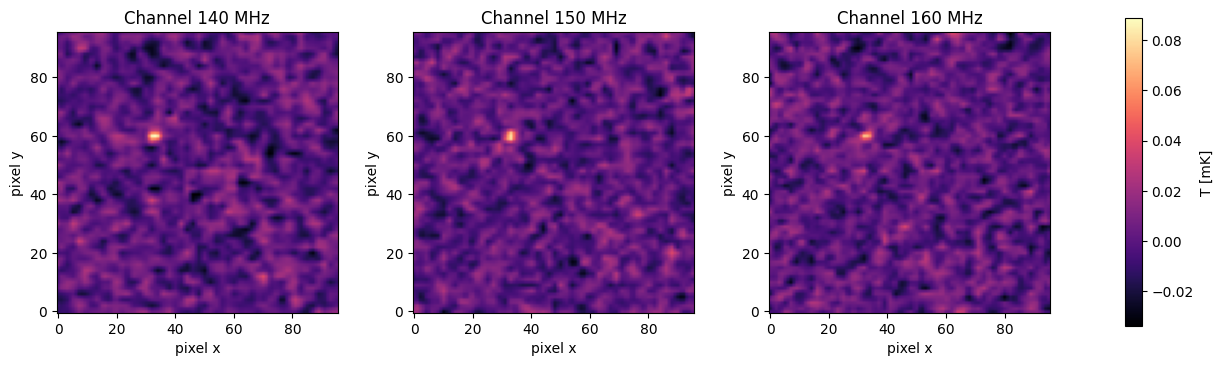

In [39]:
from matplotlib.gridspec import GridSpec

dirty_mK = dirty_cube * 1e3
vmin = dirty_mK.min()
vmax = dirty_mK.max()

fig = plt.figure(figsize=(14, 4))
gs = GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.06], wspace=0.35)
cax = fig.add_subplot(gs[0, 3])

for i in range(n_freq_cube):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(
        dirty_mK[:, :, i],
        origin='lower',
        cmap='magma',
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f'Channel {freqs_cube[i].to(units.MHz).value:.0f} MHz')
    ax.set_xlabel('pixel x')
    ax.set_ylabel('pixel y')

fig.colorbar(im, cax=cax, label='T [mK]')
plt.tight_layout()


## Summary

| Step | Method |
|------|--------|
| Baselines + redundancy | `get_bls(freq)` → `unique_bls`, `counts` |
| Half-wave UV map | `get_uvmap_halfwave(freq)` → `uv_map`, `count_map`, `array_layout` |
| **Custom UV** | `N_uv = (u_grid, v_grid, N)` or `custom_uv={...}` → `get_dirty_map`, `get_psf` |
| Model visibilities | `interp_sky_fft_to_halfwave(sky_map, freq)` |
| PSF (antenna) | `get_psf(freq)` |
| Dirty map | `get_dirty_map(sky_map, freq, noise=False)` |
| Dirty cube | `get_dirty_cube(sky_cube, freqs, ...)` — freq on last axis |
| Noise map | `get_noise_map(freq, redundancy=True)` |

**Custom UV:** pass bin **edges** and count map ``N``. Coverage is derived as ``uv_map = (N > 0)``; ``N`` is kept for redundant noise weighting.

- ``sky_map.shape`` must be ``(y_npix, x_npix)``.
- Noise requires ``T_sys``, ``t_obs``, and ``bandwidth``.


## Fringe patterns: EW-only and NS-only arrays

Colinear arrays produce 1D UV coverage. A point source yields fringe patterns that vary along **l** (EW baselines) or **m** (NS baselines).


In [21]:
n_line = 2
aperture_line = 50.0  # m

ant_ew = np.column_stack([
    np.linspace(-aperture_line / 2, aperture_line / 2, n_line),
    np.zeros(n_line),
]) * units.m

ant_ns = np.column_stack([
    np.zeros(n_line),
    np.linspace(-aperture_line / 2, aperture_line / 2, n_line),
]) * units.m

common_kw = dict(
    theta_x=theta,
    theta_y=theta,
    x_npix=npix,
    y_npix=npix,
)

inst_ew = fast_interferometer(ant_locs=ant_ew, **common_kw)
inst_ns = fast_interferometer(ant_locs=ant_ns, **common_kw)

dirty_ew = inst_ew.get_dirty_map(true_sky, freq, noise=False)
dirty_ns = inst_ns.get_dirty_map(true_sky, freq, noise=False)


2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0
2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0


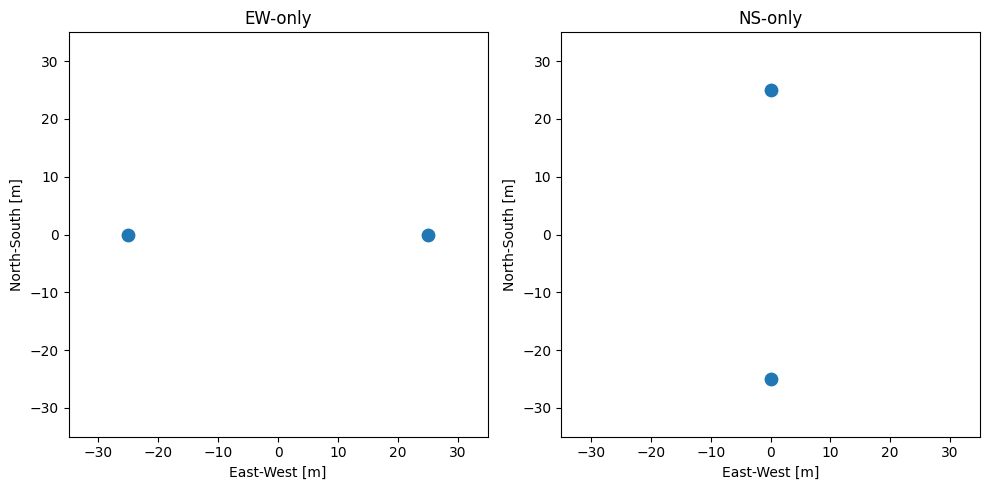

In [22]:
# plot the array layout for ew and ns side by side


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(ant_ew[:, 0].to(units.m).value, ant_ew[:, 1].to(units.m).value, s=80, c='C0')
plt.xlim(-aperture_line / 2-10, aperture_line / 2+10)
plt.ylim(-aperture_line / 2-10, aperture_line / 2+10)
plt.xlabel('East-West [m]')
plt.ylabel('North-South [m]')
plt.title('EW-only')

plt.subplot(1, 2, 2)
plt.scatter(ant_ns[:, 0].to(units.m).value, ant_ns[:, 1].to(units.m).value, s=80, c='C0')
plt.xlim(-aperture_line / 2-10, aperture_line / 2+10)
plt.ylim(-aperture_line / 2-10, aperture_line / 2+10)
plt.xlabel('East-West [m]')
plt.ylabel('North-South [m]')
plt.title('NS-only')

plt.tight_layout()



2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0
2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0


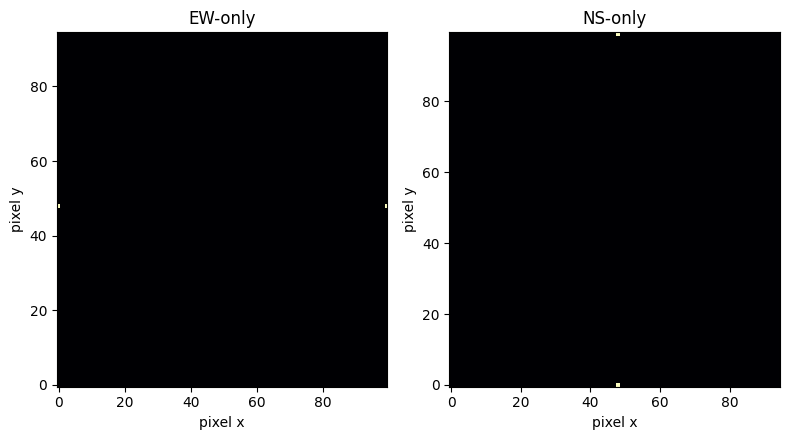

In [23]:
uv_map_ew = inst_ew.get_uvmap_halfwave(freq)
uv_map_ns = inst_ns.get_uvmap_halfwave(freq)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))

im0 = axes[0].imshow(uv_map_ew, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('EW-only')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')

im1 = axes[1].imshow(uv_map_ns, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('NS-only')
axes[1].set_xlabel('pixel x')
axes[1].set_ylabel('pixel y')
plt.tight_layout()



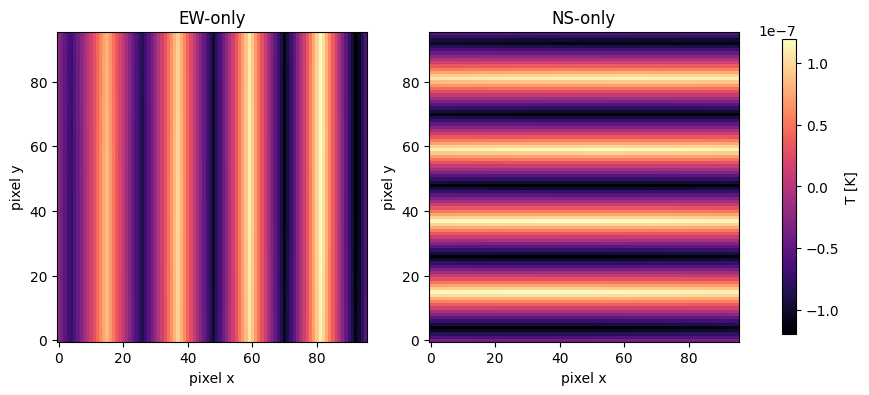

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(dirty_ew, origin='lower', cmap='magma')
axes[0].set_title('EW-only')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')

im1 = axes[1].imshow(dirty_ns, origin='lower', cmap='magma')
axes[1].set_title('NS-only')
axes[1].set_xlabel('pixel x')
axes[1].set_ylabel('pixel y')

plt.colorbar(im1, ax=axes, label='T [K]', shrink=0.85)


2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0
2 total baseline vectors, 2 unique baseline vectors
(u,v) = (0,0) is not 0 in the uv_map, setting to 0


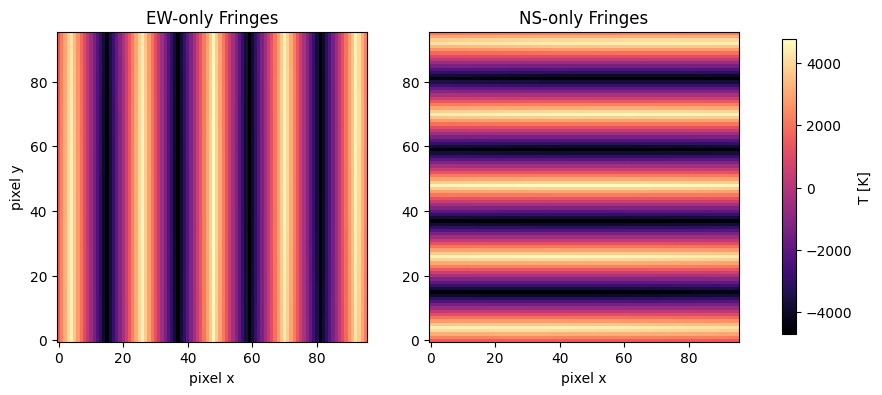

In [25]:
# output PSF for east west and north south

psf_ew = inst_ew.get_psf(freq)
psf_ns = inst_ns.get_psf(freq)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(psf_ew, origin='lower', cmap='magma')
axes[0].set_title('EW-only Fringes')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')

im1 = axes[1].imshow(psf_ns, origin='lower', cmap='magma')
axes[1].set_title('NS-only Fringes')
axes[1].set_xlabel('pixel x')

plt.colorbar(im1, ax=axes, label='T [K]', shrink=0.85)
    

## Custom UV grid (optional)

You can bypass antenna binning and pass your own UV bin **edges** and per-bin sample counts ``N``. The class stores ``N`` as ``count_map`` and builds a binary coverage mask ``uv_map`` (1 where ``N > 0``, else 0) for multiplying model visibilities.

Use either a tuple or a dict:

- ``N_uv = (u_grid, v_grid, N)``
- ``custom_uv = {'u_grid': ..., 'v_grid': ..., 'count_map': N}``

Below we build a **mock** count map on the same half-wave grid as the instrument, then form a dirty map and PSF from it.


In [26]:
# Mock N_uv on the instrument half-wave grid (edges in wavelengths)
u_grid = instrument.u_grid.copy()
v_grid = instrument.v_grid.copy()

nv_bins = len(v_grid) - 1
nu_bins = len(u_grid) - 1
mock_N = np.zeros((nv_bins, nu_bins))

mid_v = nv_bins // 2
mid_u = nu_bins // 2
mock_N[mid_v, mid_u-100] = 8.0          # EW-like redundancy ridge
mock_N[-mid_v, -(mid_u-100)] = 4.0          # EW-like redundancy ridge
mock_N[mid_v + 50, mid_u] = 3.0          # NS-like redundancy ridge
mock_N[-(mid_v + 50), -mid_u] = 3.0          # NS-like redundancy ridge

mock_N[mid_v+10 ,mid_u+10] = 12.0     # extra redundancy at center

N_uv = (u_grid, v_grid, mock_N)

uv_map_custom = instrument.get_uvmap_halfwave(freq, N_uv=N_uv)
print(f'mock_N shape: {mock_N.shape} (v bins x u bins)')
print(f'Non-zero UV bins: {(mock_N > 0).sum()} / {mock_N.size}')
print(f'uv_map is binary: {set(np.unique(uv_map_custom)) <= {0.0, 1.0}}')


mock_N shape: (636, 621) (v bins x u bins)
Non-zero UV bins: 5 / 394956
uv_map is binary: True


/var/folders/4v/cpjslnh12z99vhr9_z5vv0640000gq/T/ipykernel_32154/962595373.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 1100x450 with 4 Axes> than <Figure size 500x500 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im0, ax=axes[0], label='count')


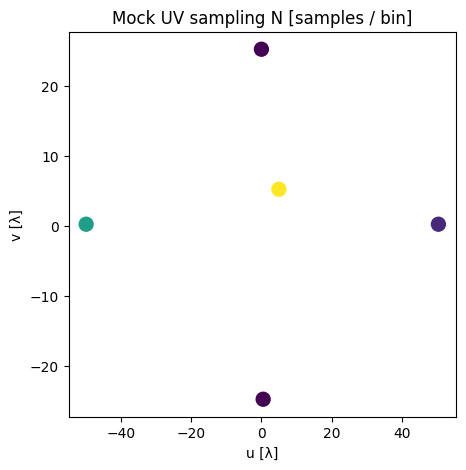

In [27]:

#make a scatter plot of the NUV with large marker size for the non-zero bins
# find the non zero N_uv values and corresponding uv coordinates 
idx = np.where(mock_N != 0)
#Find the uv coordinates of the non-zero bins
u_nonzero = u_grid[idx[1]]
v_nonzero = v_grid[idx[0]]

#make a scatter plot of the NUV with large marker size for the non-zero bins
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(u_nonzero, v_nonzero, c=mock_N[idx], cmap='viridis', s=100)
ax.set_xlabel('u [λ]')
ax.set_ylabel('v [λ]')
ax.set_title('Mock UV sampling N [samples / bin]')
plt.colorbar(im0, ax=axes[0], label='count')



In [28]:
dirty_custom = instrument.get_dirty_map(true_sky, freq, N_uv=N_uv)
psf_custom = instrument.get_psf(freq, N_uv=N_uv)

assert np.allclose(instrument.count_map, mock_N)
print(f'Custom dirty map shape: {dirty_custom.shape}')
print(f'Custom PSF shape: {psf_custom.shape}')


Custom dirty map shape: (96, 96)
Custom PSF shape: (96, 96)


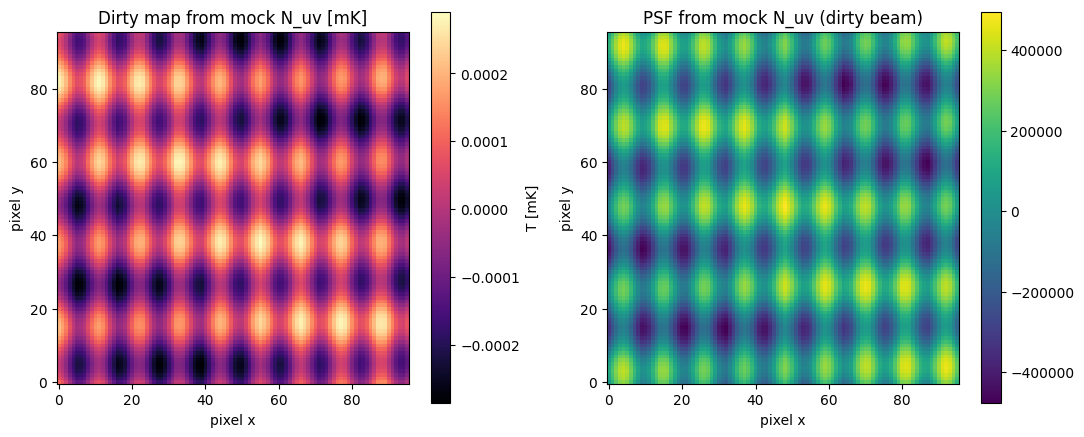

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(dirty_custom * 1e3, origin='lower', cmap='magma')
axes[0].set_title('Dirty map from mock N_uv [mK]')
axes[0].set_xlabel('pixel x')
axes[0].set_ylabel('pixel y')
plt.colorbar(im0, ax=axes[0], label='T [mK]')

im1 = axes[1].imshow(psf_custom, origin='lower', cmap='viridis')
axes[1].set_title('PSF from mock N_uv (dirty beam)')
axes[1].set_xlabel('pixel x')
axes[1].set_ylabel('pixel y')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
